In [7]:
from qitf_model import *
import numpy as np

exact_model = QITFModel(hx=0.809,J=1)
analog_model = analog_QITF(exact_model,delta=0)

import pickle

# with open('./data/analog_model[di].pkl', 'wb') as f:
#     pickle.dump(analog_model, f)

with open('./data/analog_model[d].pkl', 'rb') as f:
    analog_model = pickle.load(f)

In [8]:
initial_state = Statevector.from_label('0'*N).data  # Typical case state

fro_curve=[]
spec_curve=[]
V_fro = np.linalg.norm(analog_model.perm, 'fro')/sqrt(d)
V_spec = np.linalg.norm(analog_model.perm, 2)

estimate_fro = 0
U_int = exact_model.get_evolution_segment(segment_time=0.01)
state=initial_state
for t in np.linspace(0,10,11):
    fro_curve.append(estimate_fro)
    for i in range(10):
        estimate_fro += 0.01 * sqrt(abs(state.conj().T@(analog_model.perm.conj().T@analog_model.perm)@state))
        state = U_int @ state
for t in range(50):
    fro_curve.append(fro_curve[-1]+0.1*V_fro)

estimate_spec = 0
initial_state = Statevector.from_label('+'*N).data  # Atypical case state
state=initial_state
for t in np.linspace(0,60,61):
    spec_curve.append(estimate_spec)
    for i in range(10):
        estimate_spec += 0.01 * np.linalg.norm(analog_model.perm@state)
        state = U_int @ state

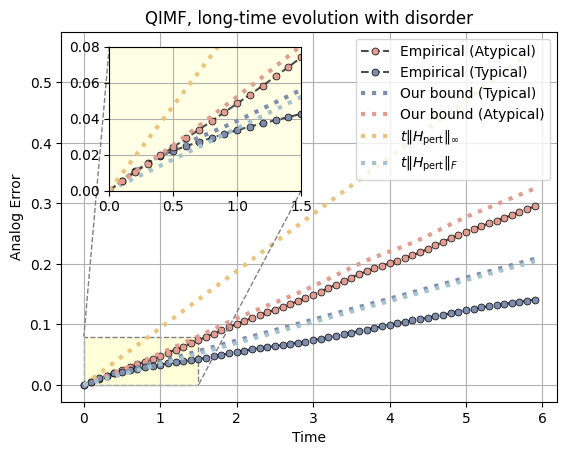

In [9]:
initial_state=Statevector.from_label('+'*N).data
    # analog_model.plot_one_segment(initial_state, mfc='#66C999', label='Separable State')
analog_model.plot_long_time(initial_state, mfc="#E19D92", label='Empirical (Atypical)')

# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
analog_model.plot_long_time(initial_state, mfc='#7E8CAD', label='Empirical (Typical)')

linear_curve=[]
for t in time:
    linear_curve.append(t*V_fro)
worst_curve =[]
for t in time:
    worst_curve.append(t*V_spec)

plt.plot(time[:-1], fro_curve[:-1], color="#7E8CAD", linestyle='dotted', label='Our bound (Typical)',linewidth=3)
plt.plot(time[:-1], spec_curve[:-1], color="#E19D92", linestyle='dotted', label='Our bound (Atypical)',linewidth=3)
plt.plot(time[:-1], worst_curve[:-1], color="#EAC47C", linestyle='dotted', label=r'$t\|H_{\text{pert}}\|_{\infty}$',linewidth=3)
plt.plot(time[:-1], linear_curve[:-1], color="#A5C2CD", linestyle='dotted', label=r'$t\|H_{\text{pert}}\|_{F}$',linewidth=3)

plt.xlabel('Time')
plt.ylabel('Analog Error')
# plt.ylim( top=0.3)
plt.legend(loc=1)
plt.title('QIMF, long-time evolution with disorder')
plt.grid()
ax1=plt.gca()

from mpl_toolkits.axes_grid1.inset_locator import mark_inset, BboxConnector

ax2=plt.axes([0.2,0.55,0.3,0.3])
ax2.set_xlim(0,1.5)
ax2.set_ylim(0,0.08)
ax2.set_facecolor("#ffffe6")

analog_model.plot_long_time(initial_state, mfc='#7E8CAD',label='Empirical (Typical)')
plt.plot(time[:-1], fro_curve[:-1], color='#7E8CAD', linestyle='dotted', linewidth=3)
plt.plot(time[:-1], linear_curve[:-1], color="#A5C2CD", linestyle='dotted', linewidth=3)
initial_state = Statevector.from_label('+'*N).data  # Atypical case state
analog_model.plot_long_time(initial_state, mfc="#E19D92", label='Atypical Case State')
plt.plot(time[:-1], spec_curve[:-1], color="#E19D92", linestyle='dotted', label='Our bound (Atypical)',linewidth=3)
plt.plot(time[:-1], worst_curve[:-1], color="#EAC47C", linestyle='dotted', label=r'$t\|H_{\text{pert}}\|_{\infty}$',linewidth=3)

plt.grid()
# plt.tight_layout()
mark_inset(ax1, ax2, loc1=2, loc2=4, fc="#ffffda", ec="0.5",linestyle='dashed')
plt.savefig('./Figures/long-time[d,c=1].pdf', bbox_inches='tight',dpi=600)
plt.show()

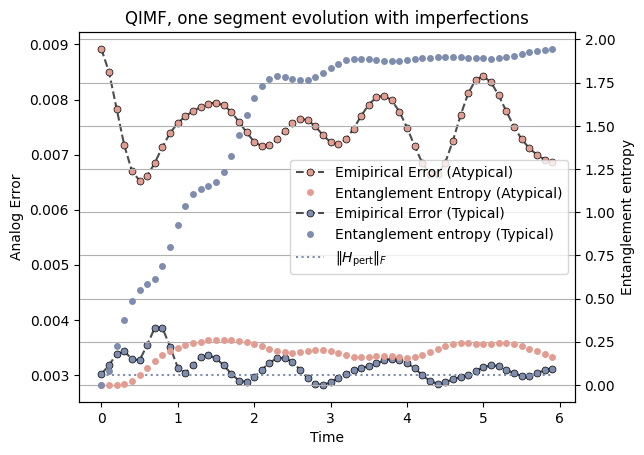

In [17]:
from entropy import entropy_data
import matplotlib.pyplot as plt

initial_state=Statevector.from_label('+'*N).data
fig, ax1 =plt.subplots()
state_distance = []
exact_state = initial_state
analog_state = initial_state
for i in range(num_steps):    
    analog_state = analog_model.U0 @ exact_state
    exact_state = analog_model.exact_model.U0 @ exact_state
    state_distance.append(np.linalg.norm(exact_state - analog_state))
p11=ax1.plot(time[:-1], state_distance, color='0.3', marker='o', markersize=5, mfc='#E19D92', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Emipirical Error (Atypical)')
ax2=ax1.twinx()
entropy_list=entropy_data(initial_state, analog_model, k=2)
p12=ax2.plot(time[:-1], entropy_list[:-1], label='Entanglement Entropy (Atypical)',marker='o', markersize=5, mfc='#E19D92', linewidth=0,markeredgewidth=0)


# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
state_distance = []
exact_state = initial_state
analog_state = initial_state
for i in range(num_steps):    
    analog_state = analog_model.U0 @ exact_state
    exact_state = analog_model.exact_model.U0 @ exact_state
    state_distance.append(np.linalg.norm(exact_state - analog_state))
p21=ax1.plot(time[:-1], state_distance, color='0.3', marker='o', markersize=5, mfc='#7E8CAD', mec='k', linestyle='dashed', markeredgewidth=0.5,label='Emipirical Error (Typical)')

entropy_list=entropy_data(initial_state, analog_model, k=2)
p22=ax2.plot(time[:-1], entropy_list[:-1],label='Entanglement entropy (Typical)',marker='o', markersize=5, mfc='#7E8CAD', linewidth=0,markeredgewidth=0)


p13=ax1.plot(time[:-1], [V_fro*time_step]*num_steps, color="#7E8CAD", linestyle='dotted', label=r'$\|H_{\text{pert}}\|_{F}$')
# plt.plot(time[:-1], [V_spec*time_step]*num_steps, color='#A4E048', linestyle='dashed', label=r'$\delta t\lambda\|V\|_{\infty}$')
ax1.set_xlabel('Time')
ax1.set_ylabel('Analog Error')
ax2.set_ylabel('Entanglement entropy')

lns=p11+p12+p21+p22+p13
labs=[l.get_label() for l in lns]
plt.title('QIMF, one segment evolution with imperfections')
plt.legend(lns,labs,loc=0)
plt.grid()
plt.savefig('./Figures/one_segment[i].pdf', bbox_inches='tight',dpi=600)
plt.show()